In [1]:
from pygel3d import hmesh, graph, jupyter_display as jd, gl_display as gl
import numpy as np
import math
from commons.utils import *
from commons.display import *
from preprocessing import voxelize
from medial_axis_formation import deep_points, postprocessing
from medial_axis_formation.postprocessing import __single_sheet, single_sheet_faces
from medial_axis_processing import unfolding
from medial_axis_processing.medial_axis import MedialAxis
from scipy.spatial import KDTree

## Load data

In [2]:
input_mesh = hmesh.load("../data/hand_v3_open.obj")
smooth_steps = 5

hmesh.quadric_simplify(input_mesh, 0.3)
hmesh.triangulate(input_mesh)
input_mesh.cleanup()

smooth(input_mesh, smooth_steps)

# display_mesh(input_mesh, wireframe=True, smooth=True, color='#b3a266')

N = input_mesh.positions().shape[0]
N

13762

## Compute Medial Axis

In [3]:
deep_points_params = { 
    "sigma_p": 5.0,
    "sigma_q": 1.5,
    "sigma_s": 3.5,
    "omega": math.radians(90),
    "curve_regularization_threshold": 0.95,
    "run_sinking_smoothing": True,
    "run_regularization": True
} # ✌︎

outer_points, inner_points = deep_points.deep_points(input_mesh, deep_points_params)

Running normal smoothing...
Running sinking of inner points...
Running skeleton formation...
Running curve point regularization...


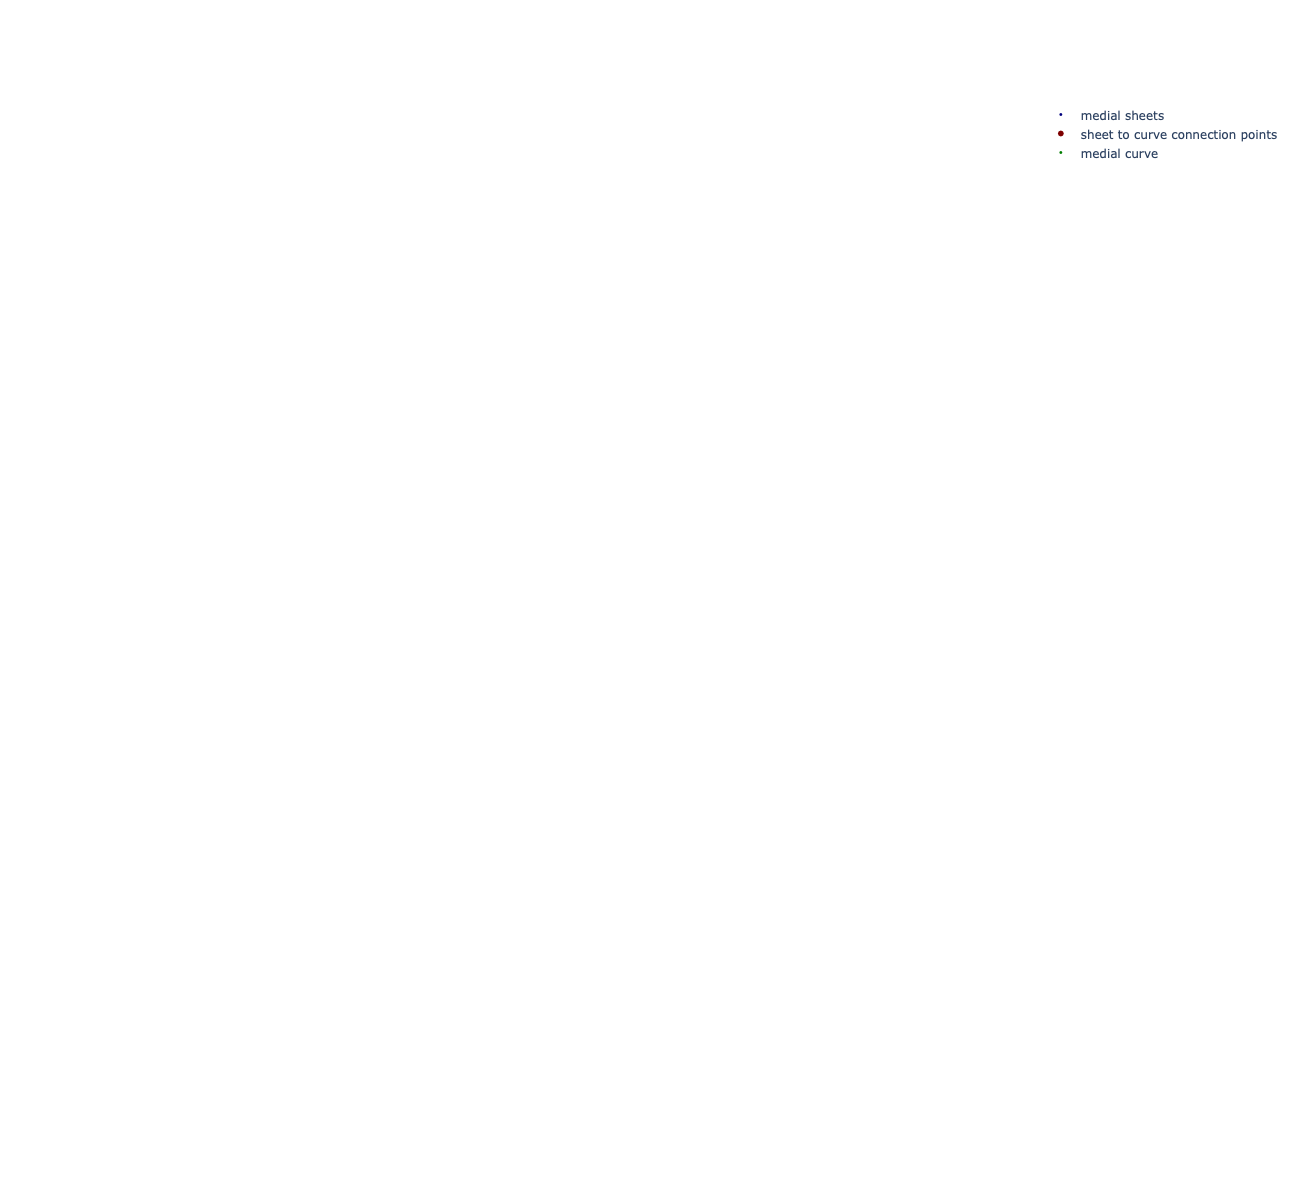

In [168]:
display_result(input_mesh, outer_points, inner_points, debug=True, show_connections=False)

In [160]:
g = graph.Graph()
for q in inner_points:
    g.add_node(q.pos)

In [161]:
dihedral_angle_threshold = 90
r = outer_points.get_average_sparsity()

# build manifold from fixed inner points (medial sheet points) 

inner_mesh = hmesh.Manifold(input_mesh)
inner_mesh.positions()[:] = inner_points.positions
for p in inner_points:
    if not p.is_fixed:
        inner_mesh.remove_vertex(p.index)

faces = np.array([inner_mesh.circulate_face(fid) for fid in inner_mesh.faces()])
trim = trimesh.Trimesh(vertices=inner_mesh.positions(), faces=faces, process=False)

# trim = manifold_to_trimesh(inner_mesh)

connected_components = trimesh.graph.connected_components(
    edges=trim.face_adjacency, nodes=np.arange(len(trim.faces))
)

edge_lengths = []
# get submeshes keeping vertex index correspondaces
for component in connected_components:    
    sub_mesh = trimesh.Trimesh(vertices=trim.vertices, faces=trim.faces[component], process=False)
    sheet_faces_indexes = single_sheet_faces(sub_mesh, dihedral_angle_threshold)
    sheet_faces = sub_mesh.faces[sheet_faces_indexes]
    
    edges = np.vstack([sheet_faces[:, [0, 1]], sheet_faces[:, [1, 2]], sheet_faces[:, [0, 2]]])

    for edge in edges:
        g.connect_nodes(edge[0], edge[1])
        edge_lengths.append(np.linalg.norm(g.positions()[edge[0]] - g.positions()[edge[1]]))

sheets_pos = np.array([g.positions()[node] for node in g.nodes() if len(g.neighbors(node)) > 0])
sheets_idx = np.array([node for node in g.nodes() if len(g.neighbors(node)) > 0])

Couldn't extract a single sheet. Try a bigger `dihedral_angle_threshold`
Couldn't extract a single sheet. Try a bigger `dihedral_angle_threshold`


In [162]:
jd.display(g)

FigureWidget({
    'data': [{'hoverinfo': 'none',
              'line': {'color': 'rgb(0,0,0)', 'width': 1},
              'mode': 'lines',
              'type': 'scatter3d',
              'uid': '11a4db7d-91f1-4b91-a0dc-68c5e06f085b',
              'x': array([-6.125228927867095, -5.849827261482413, None, ..., -3.519955984610074,
                          -3.5100198897550783, None], dtype=object),
              'y': array([0.7323183111529894, 0.7767224266803446, None, ..., -1.5416837337524887,
                          -1.5076452067102797, None], dtype=object),
              'z': array([0.9074128022946378, 0.8920529335297195, None, ..., -0.473934178755805,
                          -0.46362033842763084, None], dtype=object)}],
    'layout': {'height': 800, 'scene': {'aspectmode': 'data'}, 'template': '...', 'width': 850}
})

In [163]:
for q in inner_points:
    if not q.is_fixed:
        g.connect_nodes(q.index, inner_points[q.front_point].index)
        g.connect_nodes(q.index, inner_points[q.back_point].index)

In [164]:
jd.display(g)

FigureWidget({
    'data': [{'hoverinfo': 'none',
              'line': {'color': 'rgb(0,0,0)', 'width': 1},
              'mode': 'lines',
              'type': 'scatter3d',
              'uid': 'd72a3261-42fe-4517-9dca-6f32485e163b',
              'x': array([-6.139998227569834, -6.140133174780981, None, ..., -3.519955984610074,
                          -3.5100198897550783, None], dtype=object),
              'y': array([-5.852500465645887, -5.852804281086045, None, ..., -1.5416837337524887,
                          -1.5076452067102797, None], dtype=object),
              'z': array([-2.2131626566287914, -2.2132681355892885, None, ..., -0.473934178755805,
                          -0.46362033842763084, None], dtype=object)}],
    'layout': {'height': 800, 'scene': {'aspectmode': 'data'}, 'template': '...', 'width': 850}
})

In [165]:
sheets_idx

array([ 1143,  1144,  1145, ..., 13750, 13752, 13753])

In [166]:
kd = KDTree(sheets_pos)

for node in g.nodes():
    # find nodes with valency 1
    if len(g.neighbors(node)) == 1:
        # find closest point to it and connect them
        _, closest = kd.query(g.positions()[node], k=1)
        new_edge_len = np.linalg.norm(g.positions()[node] - sheets_pos[closest])
        print(new_edge_len, 3 * np.median(edge_lengths))  # TODO find better way to eliminate tiny edges
        if new_edge_len < 3 * np.mean(edge_lengths):
            g.connect_nodes(node, sheets_idx[closest])

4.500236081964469 0.5449106540911383
4.380899177614811 0.5449106540911383
4.403255121050758 0.5449106540911383
0.08683507121007875 0.5449106540911383
6.0907034587039375 0.5449106540911383
0.034660770884473086 0.5449106540911383
0.0075271640012663735 0.5449106540911383
6.266098546746086 0.5449106540911383
0.027085105044625208 0.5449106540911383
0.1588013726592259 0.5449106540911383
0.018311059717948004 0.5449106540911383
0.035908413927138214 0.5449106540911383
0.03669168759230456 0.5449106540911383
0.005416041426090533 0.5449106540911383
0.5819023237173038 0.5449106540911383
0.015490892061637927 0.5449106540911383
0.03072203631683163 0.5449106540911383
0.042583055176844575 0.5449106540911383
0.046021027395990295 0.5449106540911383
0.04676941183961108 0.5449106540911383
0.05837596317618203 0.5449106540911383
0.030153914026065102 0.5449106540911383
0.03970824830332576 0.5449106540911383
0.031431605806579214 0.5449106540911383
0.004731227529325602 0.5449106540911383
0.010637709948354957 0.

In [167]:
jd.display(g)

FigureWidget({
    'data': [{'hoverinfo': 'none',
              'line': {'color': 'rgb(0,0,0)', 'width': 1},
              'mode': 'lines',
              'type': 'scatter3d',
              'uid': 'd728b54d-3eb5-4148-9bc9-54b0674901c2',
              'x': array([-6.139998227569834, -6.140133174780981, None, ..., -3.519955984610074,
                          -3.5100198897550783, None], dtype=object),
              'y': array([-5.852500465645887, -5.852804281086045, None, ..., -1.5416837337524887,
                          -1.5076452067102797, None], dtype=object),
              'z': array([-2.2131626566287914, -2.2132681355892885, None, ..., -0.473934178755805,
                          -0.46362033842763084, None], dtype=object)}],
    'layout': {'height': 800, 'scene': {'aspectmode': 'data'}, 'template': '...', 'width': 850}
})